In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import tensorflow as tf
import random
import keras

2025-04-25 15:47:12.551929: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-25 15:47:12.569992: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))
from LSTM.preprocessing import parse_start_time, convert_to_datetime, create_sequences, prepare_sequences_from_cycles


In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [4]:
discharge_dataset = pd.read_csv("../../dataset/processed/discharge_data.csv")

In [5]:
discharge_dataset["start_time"] = discharge_dataset["start_time"].apply(parse_start_time)

discharge_dataset["datetime"] = discharge_dataset["start_time"].apply(convert_to_datetime)

discharge_dataset["delta_time"] = (discharge_dataset["datetime"] - discharge_dataset["datetime"].iloc[0]).dt.total_seconds()

In [6]:
discharge_data = discharge_dataset[discharge_dataset["battery_id"] == "B0005"].copy()

## Extract features

### Take 175 timesteps in each of the cycle, and then concatenate 168 cycles, each cycle have 5 features

In [7]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data, data_path, columns)

100%|██████████| 168/168 [00:00<00:00, 551.20it/s]


In [8]:
# (cycles, each rows in a cycle, features)
X.shape

(168, 175, 5)

In [9]:
timesteps = X.shape[1]
features = X.shape[2]
latent_dim = 12

In [10]:
from keras.api.models import Model, Sequential
from keras.api.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from keras.api.utils import plot_model
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError

input_layer = Input(shape=(timesteps, features))
encoded = LSTM(64, activation='sigmoid', return_sequences=True)(input_layer)
encoded = LSTM(32, activation='sigmoid', return_sequences=False)(encoded)
encoded = Dense(latent_dim, activation='relu', name='bottleneck')(encoded)

decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(32, activation='sigmoid', return_sequences=True)(decoded)
decoded = LSTM(64, activation='sigmoid', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features, activation='linear'))(decoded)


autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [11]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 175, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 175, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 175, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 175, 32)        │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 175, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 175, 5)         │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,649 (240.82 KB)

 Trainable params: 61,649 (240.82 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('autoencoder/best_autoencoder.keras', save_best_only=True)
]

autoencoder.fit(X, X, epochs=100, batch_size=32, validation_split=0.2, callbacks=callbacks, verbose=1)

Epoch 1/100


2025-04-25 15:47:18.416553: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 304ms/step - loss: 0.2335 - root_mean_squared_error: 0.4819 - val_loss: 0.0763 - val_root_mean_squared_error: 0.2762
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0655 - root_mean_squared_error: 0.2557 - val_loss: 0.0192 - val_root_mean_squared_error: 0.1385
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0572 - root_mean_squared_error: 0.2390 - val_loss: 0.0264 - val_root_mean_squared_error: 0.1626
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0628 - root_mean_squared_error: 0.2507 - val_loss: 0.0224 - val_root_mean_squared_error: 0.1496
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0494 - root_mean_squared_error: 0.2223 - val_loss: 0.0308 - val_root_mean_squared_error: 0.1756
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0490 - root_mean_squared_error: 0.2214 - val_loss: 0.0394 - val_root_mean_squared_error: 0.1985
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0521 - root

In [13]:
encoded_features = encoder.predict(X)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [14]:
encoded_features.shape

(168, 12)

In [15]:
capacity = discharge_data["Capacity"]

In [16]:
capacity.shape

(168,)

In [17]:
from sklearn.preprocessing import MinMaxScaler

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

In [18]:
combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1))) # (168, 33)

In [19]:
# (Cycles, seq_len, features)
combined_features.shape

(168, 13)

In [20]:
seq_len = 20  # How many past cycles to use for prediction
n_out = 20

X, y = create_sequences(combined_features, seq_len)

X_train, y_train = X[:140], y[:140]
X_val, y_val = X[140:], y[140:]

In [21]:
X.shape, y.shape

((148, 20, 13), (148, 13))

In [22]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((140, 20, 13), (140, 13), (8, 20, 13), (8, 13))

# Encoder-Decoder Model for future prediction

In [23]:
# df_combined = pd.DataFrame(combined_features)

In [24]:
# X_sequences, y_labels = create_sequence(df_combined, seq_length=15, target=100)

In [25]:
# print("X_sequences shape:", .shape)  # (128, 20, 33)
# print("y_labels shape:", y_seq.shape) # (128, 20, 33)

In [26]:
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

timesteps, n_features

(20, 13)

In [27]:
X_train.shape, y_train.shape

((140, 20, 13), (140, 13))

In [28]:
from keras.api.models import Sequential
from keras.api.layers import LSTM, RepeatVector, TimeDistributed, Dense, InputLayer, Dropout

model = Sequential()

model.add(InputLayer((timesteps, n_features)))

model.add(LSTM(64, return_sequences=True, activation='tanh'))

model.add(LSTM(32, return_sequences=True, activation='tanh'))

model.add(LSTM(16, return_sequences=False, activation='tanh'))

model.add(Dense(16, activation='relu'))

model.add(Dense(latent_dim + 1, activation='linear'))

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 20, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 20, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │           221 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,013 (140.68 KB)

 Trainable params: 36,013 (140.68 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError
from keras.api.regularizers import L2

# Callback to stop training when validation loss stops improving
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

cp = ModelCheckpoint('models/model.keras', save_best_only=True, monitor='val_loss')
model.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [31]:
model.fit(X, y, epochs=100, callbacks=[es, cp])

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0672 - root_mean_squared_error: 0.2591
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0568 - root_mean_squared_error: 0.2383 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0512 - root_mean_squared_error: 0.2263 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0473 - root_mean_squared_error: 0.2174 
Epoch 5/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0443 - root_mean_squared_error: 0.2104

/home/nghiemxuandat/miniconda3/envs/battery/lib/python3.11/site-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,root_mean_squared_error
  current = self.get_monitor_value(logs)
/home/nghiemxuandat/miniconda3/envs/battery/lib/python3.11/site-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0431 - root_mean_squared_error: 0.2076 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0391 - root_mean_squared_error: 0.1978 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0350 - root_mean_squared_error: 0.1872 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0310 - root_mean_squared_error: 0.1761 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0270 - root_mean_squared_error: 0.1642 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0229 - root_mean_squared_error: 0.1514 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0190 - root_mean_squared_error: 0.1378 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0153 - root_mean_squared_error: 0.1237
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0120 - root_mean_squared_error: 0.1096 
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0092 - root_mean_squared_error: 0.0958 
Epoch 15/100
5/5 

In [32]:
# X_test = X_test.reshape(1, n_in, features) # (1, 20, 33)
# X_test.shape

In [33]:
initial_input = combined_features[:seq_len] # (20, 33)
X_input = initial_input.reshape(1, seq_len, latent_dim + 1) # first n_in cycles -> (1, 20, 33)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = capacity[-1]

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold voltage: {threshold} Ah")

Initial capacity: 1.8564874208181568 Ah
Threshold voltage: 1.3250793286429356 Ah


In [34]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + seq_len + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + seq_len + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

Predicted capacity for cycle 21: 1.8191300840315676
Predicted capacity for cycle 22: 1.8153086078659633
Predicted capacity for cycle 23: 1.812145395223555
Predicted capacity for cycle 24: 1.809894315770003
Predicted capacity for cycle 25: 1.8077751060906773
Predicted capacity for cycle 26: 1.8057974664827563
Predicted capacity for cycle 27: 1.8038389222150846
Predicted capacity for cycle 28: 1.8019765669082426
Predicted capacity for cycle 29: 1.8007129505737312
Predicted capacity for cycle 30: 1.7994519458576905
Predicted capacity for cycle 31: 1.7981275161216386
Predicted capacity for cycle 32: 1.7967164281363204
Predicted capacity for cycle 33: 1.7958199646582904
Predicted capacity for cycle 34: 1.7947599867302746
Predicted capacity for cycle 35: 1.7935249286133295
Predicted capacity for cycle 36: 1.7927303860899166
Predicted capacity for cycle 37: 1.7916924203747282
Predicted capacity for cycle 38: 1.7903689742352435
Predicted capacity for cycle 39: 1.788783925326055
Predicted capac

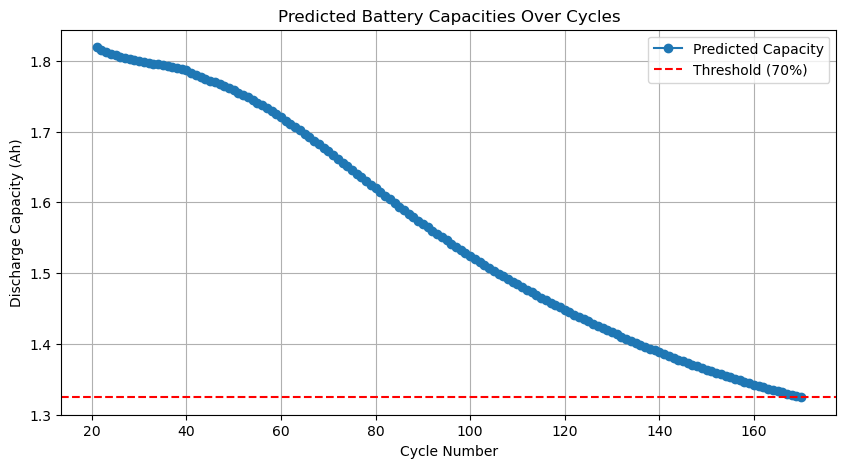

In [35]:
import matplotlib.pyplot as plt

# Create an array for cycle numbers starting from n_in
cycles = list(range(seq_len + 1, seq_len + len(predicted_capacities) + 1))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(cycles, predicted_capacities, marker='o', label='Predicted Capacity')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold (70%)')
plt.title("Predicted Battery Capacities Over Cycles")
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (Ah)")
plt.legend()
plt.grid(True)
plt.show()

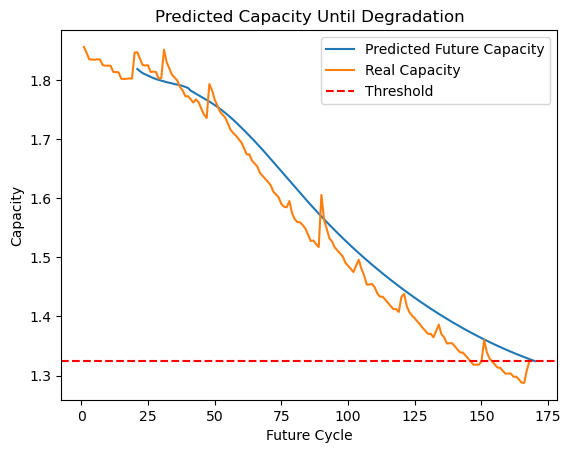

In [36]:
import matplotlib.pyplot as plt

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data["cycle_number"], discharge_data["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()

In [37]:
true_capacities = discharge_data["Capacity"].values[seq_len:]

predicted_capacities = predicted_capacities[:len(true_capacities)]

len(true_capacities), len(predicted_capacities)

(148, 148)

In [38]:
test_results = pd.DataFrame(data={'Predictions': predicted_capacities, 'Actuals': true_capacities})
test_results

,Predictions,Actuals
0,1.819130,1.847417
1,1.815309,1.836177
2,1.812145,1.825781
3,1.809894,1.825114
4,1.807775,1.825582
...,...,...
143,1.334710,1.293464
144,1.332915,1.288003
145,1.331152,1.287453
146,1.329422,1.309015


In [39]:
# Compute RMSE
rmse = np.sqrt(mean_squared_error(true_capacities, predicted_capacities))

print(f"Mean Squared Error: {rmse:.4f}")

Mean Squared Error: 0.0354


## Test on other batteries

In [ ]:
discharge_data_b0006 = discharge_dataset[discharge_dataset["battery_id"] == "B0006"].copy()

In [41]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data_b0006, data_path, columns)

100%|██████████| 168/168 [00:00<00:00, 471.49it/s]


In [42]:
encoded_features = encoder.predict(X)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [43]:
capacity = discharge_data_b0006["Capacity"]

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [44]:
X, y = create_sequences(combined_features, seq_len)

initial_input = combined_features[:seq_len] # (20, 33)
X_input = initial_input.reshape(1, seq_len, latent_dim + 1) # first n_in cycles -> (1, 20, 33)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = capacity[-1]

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold capacity: {threshold} Ah")

Initial capacity: 1.89105229539079 Ah
Threshold capacity: 1.4324552720625434 Ah


In [45]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)  # shape: (1, 1, 33)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + seq_len + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + seq_len + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

Predicted capacity for cycle 21: 1.8683751427381021
Predicted capacity for cycle 22: 1.8658916605366922
Predicted capacity for cycle 23: 1.86416454836933
Predicted capacity for cycle 24: 1.8626089104878902
Predicted capacity for cycle 25: 1.8611999205504985
Predicted capacity for cycle 26: 1.859994337013665
Predicted capacity for cycle 27: 1.858851067887353
Predicted capacity for cycle 28: 1.857610452598382
Predicted capacity for cycle 29: 1.8563328463524378
Predicted capacity for cycle 30: 1.855876263900121
Predicted capacity for cycle 31: 1.8553925742405992
Predicted capacity for cycle 32: 1.8548945560680996
Predicted capacity for cycle 33: 1.8549932181146038
Predicted capacity for cycle 34: 1.8550113480698003
Predicted capacity for cycle 35: 1.8549125398139799
Predicted capacity for cycle 36: 1.8546789265687154
Predicted capacity for cycle 37: 1.8543670913393375
Predicted capacity for cycle 38: 1.8545971370772891
Predicted capacity for cycle 39: 1.8546050616222218
Predicted capacity

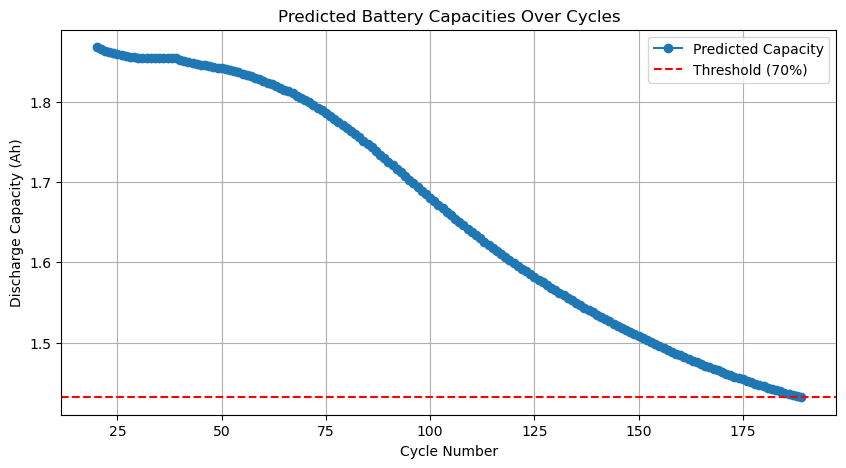

In [46]:
import matplotlib.pyplot as plt

# Create an array for cycle numbers starting from n_in
cycles = list(range(seq_len, seq_len + len(predicted_capacities)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(cycles, predicted_capacities, marker='o', label='Predicted Capacity')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold (70%)')
plt.title("Predicted Battery Capacities Over Cycles")
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (Ah)")
plt.legend()
plt.grid(True)
plt.show()

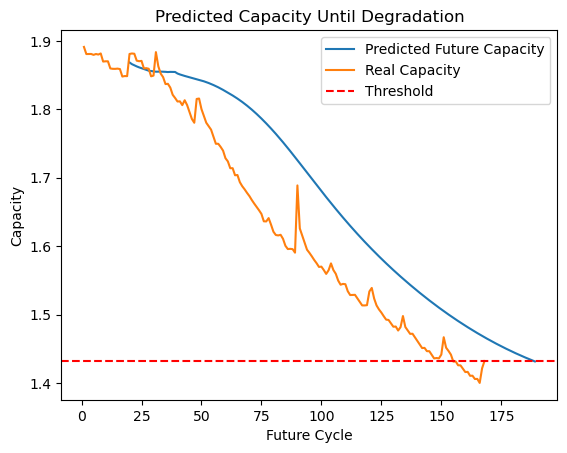

In [47]:
import matplotlib.pyplot as plt

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_b0006["cycle_number"], discharge_data_b0006["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()

## Battery from other batch with different temperature (B0029 - 43C)

In [48]:
discharge_data_b0029 = discharge_dataset[discharge_dataset["battery_id"] == "B0029"].copy()

In [49]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data_b0029, data_path, columns)

encoded_features = encoder.predict(X)

100%|██████████| 40/40 [00:00<00:00, 510.58it/s]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [50]:
capacity = discharge_data_b0029["Capacity"]

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [51]:
X, y = create_sequences(combined_features, seq_len)

initial_input = combined_features[:seq_len] # (20, 33)
X_input = initial_input.reshape(1, seq_len, latent_dim + 1) # first n_in cycles -> (1, 20, 33)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = capacity[-1]

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold capacity: {threshold} Ah")

Initial capacity: 1.697507332205763 Ah
Threshold capacity: 1.612079811711934 Ah


In [52]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)  # shape: (1, 1, 33)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + seq_len + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + seq_len + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

Predicted capacity for cycle 21: 1.7614354665042031
Predicted capacity for cycle 22: 1.7617682895406095
Predicted capacity for cycle 23: 1.7557328701649129
Predicted capacity for cycle 24: 1.7509567264854538
Predicted capacity for cycle 25: 1.74688331859812
Predicted capacity for cycle 26: 1.7431630048386448
Predicted capacity for cycle 27: 1.7396173247295421
Predicted capacity for cycle 28: 1.7363218442410004
Predicted capacity for cycle 29: 1.7336150434582036
Predicted capacity for cycle 30: 1.7314031096555922
Predicted capacity for cycle 31: 1.729568797724191
Predicted capacity for cycle 32: 1.7274137602442714
Predicted capacity for cycle 33: 1.7257158552880476
Predicted capacity for cycle 34: 1.7243425651013766
Predicted capacity for cycle 35: 1.7229194152396965
Predicted capacity for cycle 36: 1.7218296915556524
Predicted capacity for cycle 37: 1.7194037604715926
Predicted capacity for cycle 38: 1.717419904178453
Predicted capacity for cycle 39: 1.7157969689838461
Predicted capaci

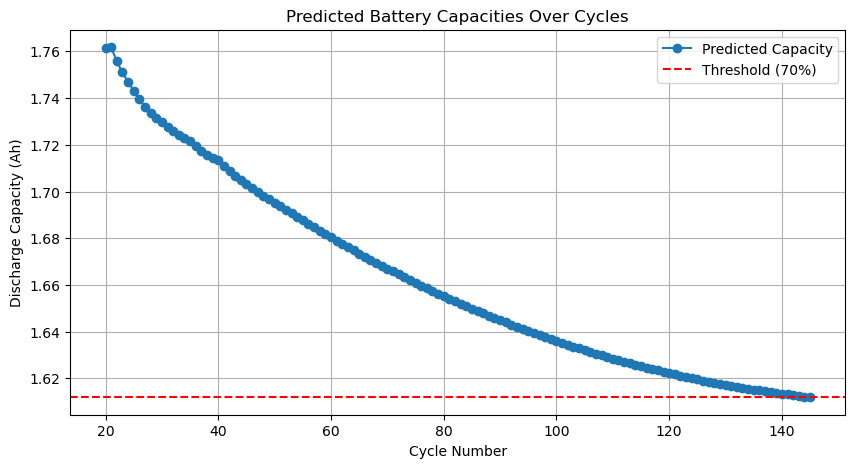

In [53]:
import matplotlib.pyplot as plt

# Create an array for cycle numbers starting from n_in
cycles = list(range(seq_len, seq_len + len(predicted_capacities)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(cycles, predicted_capacities, marker='o', label='Predicted Capacity')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold (70%)')
plt.title("Predicted Battery Capacities Over Cycles")
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (Ah)")
plt.legend()
plt.grid(True)
plt.show()

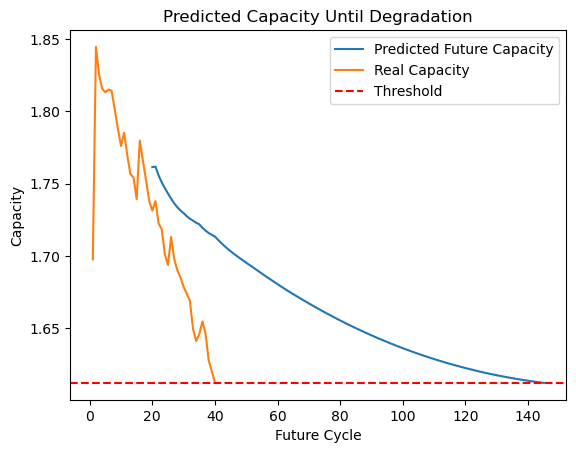

In [55]:
import matplotlib.pyplot as plt

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_b0029["cycle_number"], discharge_data_b0029["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()